# SQL-IDS: Tek Notebook Akisi (Detayli Aciklamali)

Bu notebook SQL Injection (SQLi) tespiti icin tek dosyada adim adim makine ogrenmesi akisi sunar.

Veri `merge_clean_preprocess.ipynb` ciktisindan yuklenir. Overfitting riskini azaltmak icin
train / validation / test ayrimi, regularize modeller ve train-validation gap analizi uygulanir.

## 1) Hazirlik ve Veri Yukleme

Bu bolumde kutuphaneler import edilir ve `merge_clean_preprocess.ipynb` ciktisi olan hazir dataset yuklenir.

In [16]:
# Standart kutuphaneler
import os  # Dosya/klasor islemleri icin
import pickle  # Model ve vectorizer kaydetme/yukleme icin

# Veri ve gorsellestirme kutuphaneleri
import pandas as pd  # Tablo islemleri
import seaborn as sns  # Islenmis grafikler
import matplotlib.pyplot as plt  # Temel grafik cizimi

# Makine ogrenmesi kutuphaneleri
from sklearn.feature_extraction.text import TfidfVectorizer  # Metni sayisallastirma
from sklearn.model_selection import train_test_split  # Train/test ayirma
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
)  # Degerlendirme metrikleri
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # RF + Ensemble modeli
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier  # XGBoost siniflandirici

# Grafik temasini ve varsayilan boyutu belirle
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Veri yukleme

`data/merged_cleaned_preprocessed.csv` dosyasi okunur. Bu dosyada `Sentence` ve `Label` (0/1) kolonlari
`merge_clean_preprocess.ipynb` icinde zaten hazirlanmistir.

In [17]:
# Hazir dataset (merge_clean_preprocess.ipynb ciktisi)
DATASET_PATH = "./data/merged_cleaned_preprocessed.csv"

df = pd.read_csv(DATASET_PATH, low_memory=False)

required_cols = {"Sentence", "Label"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Dataset eksik kolonlar: {missing}")

print("Veri boyutu:", df.shape)
print("Label dagilimi:")
print(df["Label"].value_counts())

df.head()

Veri boyutu: (1665053, 4)
Label dagilimi:
Label
0    1490101
1     174952
Name: count, dtype: int64


,Sentence,normalized_query,Label,dataset_source
0,"SELECT n.type, c.name as country_name, COUNT(n...","select n.type, c.name as country_name, count(n...",0,better
1,"SELECT a.id, a.ident, a.name, a.latitude_deg, ...","select a.id, a.ident, a.name, a.latitude_deg, ...",0,better
2,UPDATE airport_frequencies SET type = 'TWR' WH...,update airport_frequencies set type = 'twr' wh...,0,better
3,"SELECT name, 'airport' AS type FROM airport WH...","select name, 'airport' as type from airport wh...",0,better
4,"SELECT name, 'airport' AS entity_type FROM air...","select name, 'airport' as entity_type from air...",0,better


In [18]:
import numpy as np

# Kaynak etiketi: SQLiV3 vs "better" dataset (ham dosyalardan Sentence eslesmesi)
PATH_SQLIV3 = "./data/SQLiV3.csv"
PATH_BETTER = "./data/looking for beter dataset/dataset.csv"

sqliv3_raw = pd.read_csv(PATH_SQLIV3, encoding="UTF-8")
sqliv3_raw = sqliv3_raw.drop(columns=["Unnamed: 2", "Unnamed: 3"], errors="ignore")
sqliv3_sentences = set(sqliv3_raw["Sentence"].astype(str))

df["dataset_source"] = np.where(
    df["Sentence"].astype(str).isin(sqliv3_sentences),
    "sqliv3",
    "better",
)

print("\nKaynak dagilimi (tum dataset):")
print(df["dataset_source"].value_counts())
print("\nLabel x kaynak:")
print(pd.crosstab(df["Label"], df["dataset_source"]))


Kaynak dagilimi (tum dataset):
dataset_source
better    1638869
sqliv3      26184
Name: count, dtype: int64

Label x kaynak:
dataset_source   better  sqliv3
Label                          
0               1473362   16739
1                165507    9445


## 2) Vektorlestirme ve Modelleme Hazirligi

Veri uc parcaya ayrilir (data leakage onlenir):
- **Train** (%68): model egitimi
- **Validation** (%12): overfitting izleme (train–val metrik karsilastirmasi)
- **Test** (%20): nihai performans (holdout)

TF-IDF yalnizca train uzerinde fit edilir; val ve test transform edilir.

### Once bol, sonra vektorize et (data leakage onleme)

1. **Ham metin:** `train_test_split` ile `X_train`, `X_val`, `X_test` (metin; henuz TF-IDF yok)
2. **Train:** `fit_transform(X_train)` — vektorizer yalnizca egitim kelime dagarcigini ogrenir
3. **Val / Test:** `transform(...)` — `fit` yapilmaz; holdout metin vektorizer tarafindan gorulmez

In [19]:
# --- 1) Ham metin: once bol (TF-IDF oncesi; tum X uzerinde fit YOK) ---
X = df["Sentence"]
y = df["Label"]

TEST_SIZE = 0.20
VAL_SIZE = 0.15

# Holdout test
X_remain, X_test, y_remain, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y,
)

# Validation (kalan havuzun %15'i)
X_train, X_val, y_train, y_val = train_test_split(
    X_remain,
    y_remain,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=y_remain,
)

# Kaynak / hata analizi icin orijinal dataframe indeksleri (TF-IDF sonrasi X_* matris olur)
idx_test = X_test.index
idx_train = X_train.index
idx_val = X_val.index

# --- 2) TF-IDF: yalnizca train'de fit + transform; val/test sadece transform ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000, analyzer="char_wb", ngram_range=(3, 5))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Sonraki hucrelerde kullanilan matris takma adlari (sparse TF-IDF)
X_train, X_val, X_test = X_train_tfidf, X_val_tfidf, X_test_tfidf

print("Train shape     :", X_train_tfidf.shape, "| Label:", dict(y_train.value_counts()))
print("Validation shape:", X_val_tfidf.shape, "| Label:", dict(y_val.value_counts()))
print("Test shape      :", X_test_tfidf.shape, "| Label:", dict(y_test.value_counts()))
print("Vocabulary size (train-only fit):", len(tfidf_vectorizer.vocabulary_))

Train shape     : (1132235, 5000) | Label: {0: np.int64(1013267), 1: np.int64(118968)}
Validation shape: (199807, 5000) | Label: {0: np.int64(178813), 1: np.int64(20994)}
Test shape      : (333011, 5000) | Label: {0: np.int64(298021), 1: np.int64(34990)}
Vocabulary size (train-only fit): 5000


## 3) Bireysel Model Egitimi ve Kayit

Regularize edilmis modeller yalnizca **train** setinde egitilir:
- XGBoost (L1/L2, subsample; sabit agac sayisi — ensemble uyumlulugu icin early stopping yok)
- Random Forest (sinirli derinlik, min_samples_leaf)
- SGD / Logistic Regression (L2, class_weight='balanced')

Ardindan modeller ve vectorizer `models/` klasorune kaydedilir.

In [20]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier

# Sinif dengesizligi
oran = (y_train == 0).sum() / (y_train == 1).sum()
print(f"XGBoost scale_pos_weight (sinif 0/1 orani): {oran:.4f}")

# XGBoost: regularizasyon (early_stopping VotingClassifier ile uyumsuz; n_estimators sabit)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=oran,
)
xgb_model.fit(X_train, y_train)

# Random Forest: daha sig agaclar
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)
rf_model.fit(X_train, y_train)

# SGD: L2 regularizasyon
sgd_model = SGDClassifier(
    loss="log_loss",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-3,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)
sgd_model.fit(X_train, y_train)

# Logistic Regression: daha guclu regularizasyon (dusuk C)
lr_model = LogisticRegression(
    C=0.1,
    max_iter=2000,
    random_state=42,
    class_weight="balanced",
)
lr_model.fit(X_train, y_train)

models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "SGD (Linear SVM)": sgd_model,
    "Logistic Regression": lr_model,
}

import numpy as np

POS_LABEL = 1


def positive_scores(model, X):
    """Pozitif sinif (SQLi) olasilik veya skor vektoru."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, POS_LABEL]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X).astype(float)


def split_metrics(model, X, y_true):
    """Tek split icin siniflandirma + ROC-AUC / PR-AUC."""
    y_true_arr = np.asarray(y_true)
    y_pred = model.predict(X)
    y_score = positive_scores(model, X)
    out = {
        "Accuracy": accuracy_score(y_true_arr, y_pred),
        "Precision": precision_score(y_true_arr, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_true_arr, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1-Score": f1_score(y_true_arr, y_pred, pos_label=POS_LABEL, zero_division=0),
    }
    if len(np.unique(y_true_arr)) > 1:
        out["ROC-AUC"] = roc_auc_score(y_true_arr, y_score)
        out["PR-AUC"] = average_precision_score(y_true_arr, y_score)
    else:
        out["ROC-AUC"] = np.nan
        out["PR-AUC"] = np.nan
    return out


print("Tum modeller train seti uzerinde egitildi.")

XGBoost scale_pos_weight (sinif 0/1 orani): 8.5171
Tum modeller train seti uzerinde egitildi.


### Train vs Validation: Overfitting Analizi

Her model icin train ve validation metrikleri karsilastirilir (ROC-AUC / PR-AUC dahil).
- **Gap** (Train - Validation): buyuk pozitif fark overfitting belirtisidir.
- Cikti: `plots/train_val_metrics.csv`, `plots/train_val_gap.png`


Train vs Validation metrikleri:

                        Train                                                   Validation                                                   Gap (Train-Val)                                                  
Metric               Accuracy  F1-Score    PR-AUC Precision   ROC-AUC    Recall   Accuracy  F1-Score    PR-AUC Precision   ROC-AUC    Recall        Accuracy  F1-Score    PR-AUC Precision   ROC-AUC    Recall
Model                                                                                                                                                                                                         
Logistic Regression  0.993162  0.967271  0.981196  0.972980  0.993662  0.961628   0.993258  0.967719  0.980822  0.973810  0.993061  0.961703   -9.629755e-05 -0.000448  0.000373 -0.000830  0.000600 -0.000075
Random Forest        0.987935  0.943587  0.981129  0.927477  0.993434  0.960267   0.987758  0.942816  0.980572  0.925803  0.992926  0.96046

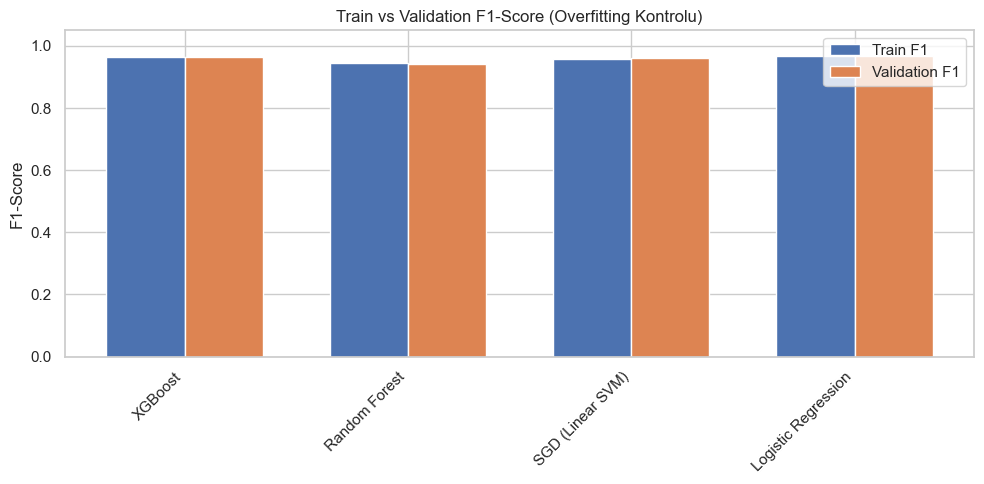

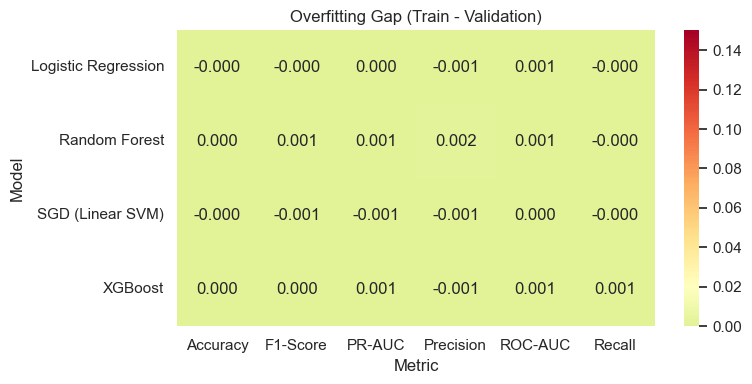


Kaydedildi: ./plots/train_val_metrics.csv, ./plots/train_val_gap.png


In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("plots", exist_ok=True)

METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

train_val_rows = []
for model_name, model in models.items():
    train_m = split_metrics(model, X_train, y_train)
    val_m = split_metrics(model, X_val, y_val)
    for metric in METRIC_COLS:
        gap = train_m[metric] - val_m[metric]
        train_val_rows.append(
            {
                "Model": model_name,
                "Metric": metric,
                "Train": train_m[metric],
                "Validation": val_m[metric],
                "Gap (Train-Val)": gap,
            }
        )

train_val_df = pd.DataFrame(train_val_rows)
train_val_df.to_csv("./plots/train_val_metrics.csv", index=False, float_format="%.6f")

print("Train vs Validation metrikleri:\n")
pivot = train_val_df.pivot(index="Model", columns="Metric", values=["Train", "Validation", "Gap (Train-Val)"])
print(pivot.to_string())

# Ortalama gap ozeti
gap_summary = (
    train_val_df.groupby("Model")["Gap (Train-Val)"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="Mean_Gap")
)
print("\nOrtalama metrik farki (Train - Validation), yuksek = daha fazla overfitting riski:\n")
print(gap_summary.to_string(index=False))

# Gorsel: F1 gap
f1_gap = train_val_df[train_val_df["Metric"] == "F1-Score"].copy()
plt.figure(figsize=(10, 5))
x = range(len(f1_gap))
width = 0.35
plt.bar([i - width / 2 for i in x], f1_gap["Train"], width, label="Train F1")
plt.bar([i + width / 2 for i in x], f1_gap["Validation"], width, label="Validation F1")
plt.xticks(x, f1_gap["Model"], rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("F1-Score")
plt.title("Train vs Validation F1-Score (Overfitting Kontrolu)")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/train_val_gap.png", dpi=150)
plt.show()
plt.close()

# Tum metrikler icin gap heatmap
gap_pivot = train_val_df.pivot(index="Model", columns="Metric", values="Gap (Train-Val)")
plt.figure(figsize=(8, 4))
sns.heatmap(gap_pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", center=0.02, vmin=0, vmax=0.15)
plt.title("Overfitting Gap (Train - Validation)")
plt.tight_layout()
plt.savefig("./plots/train_val_gap_heatmap.png", dpi=150)
plt.show()
plt.close()

print("\nKaydedildi: ./plots/train_val_metrics.csv, ./plots/train_val_gap.png")

### Modellerin ve TF-IDF nesnesinin kaydedilmesi

Bu adim yeniden egitim yapmadan modeli tekrar kullanabilmek icin gereklidir.
Model ve vectorizer artefaktlari `models/` klasorune yazilir.

In [22]:
import os
import pickle

# Model artefaktlarini yazmak icin klasor olustur (yoksa)
os.makedirs("models", exist_ok=True)

# XGBoost modelini kaydet
with open("./models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Random Forest modelini kaydet
with open("./models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# SGD modelini kaydet
with open("./models/sgd_model.pkl", "wb") as f:
    pickle.dump(sgd_model, f)

# Logistic Regression modelini kaydet
with open("./models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# TF-IDF vectorizer nesnesini kaydet
with open("./models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Tum modeller ve vectorizer basariyla kaydedildi.")

Tum modeller ve vectorizer basariyla kaydedildi.


## 4) Performans Degerlendirmesi (Holdout Test)

Bu bolumde modeller **daha once hic kullanilmayan test** seti uzerinde degerlendirilir.
Train/validation analizi (Bolum 3.1) overfitting icin yapildi; burada genelleme performansi olculur.
- Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC (SQLi = pozitif sinif 1)
- Confusion matrix (`plots/`)
- `plots/model_metrics.csv`
- **4.1** Imbalance-aware metrikler: majority baseline, balanced accuracy, MCC, ROC/PR-AUC, hata ornekleri
- **4.2** Kaynak bazli test analizi (SQLiV3 vs better)
- **4.3** Validation esik optimizasyonu (Logistic Regression)
- **4.4** Capraz kaynak OOD: yalnizca better ile egitim, SQLiV3 test alt kumesi

In [23]:
import pickle

# Daha once kaydedilen model dosyalarini tekrar yukle
# Bu adim yeniden egitim yapmadan degerlendirme icin kullanilir.
with open("./models/xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("./models/random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("./models/sgd_model.pkl", "rb") as f:
    sgd_model = pickle.load(f)

with open("./models/logistic_regression_model.pkl", "rb") as f:
    lr_model = pickle.load(f)
 
# TF-IDF vectorizer nesnesini yukle
with open("./models/tfidf_vectorizer.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)

print("Tum modeller ve vectorizer basariyla yuklendi.")

# Gerekirse manuel test icin ornek kod:
# raw_texts = ["ornek metin 1", "ornek metin 2"]
# X_new_tfidf = tfidf_vectorizer.transform(raw_texts)  # yeni veri: sadece transform
# y_pred = ensemble_model.predict(X_new_tfidf)
# print(y_pred)

Tum modeller ve vectorizer basariyla yuklendi.



===== XGBoost =====
Accuracy : 0.9924
Precision: 0.9626
Recall   : 0.9652
F1-Score : 0.9639
ROC-AUC  : 0.9938
PR-AUC   : 0.9830
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    298021
           1       0.96      0.97      0.96     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.98      0.98    333011
weighted avg       0.99      0.99      0.99    333011



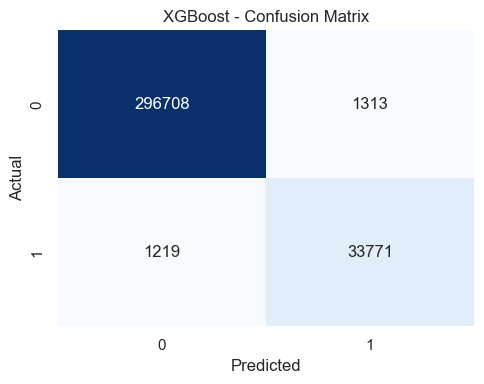


===== Random Forest =====
Accuracy : 0.9876
Precision: 0.9257
Recall   : 0.9590
F1-Score : 0.9421
ROC-AUC  : 0.9931
PR-AUC   : 0.9805
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    298021
           1       0.93      0.96      0.94     34990

    accuracy                           0.99    333011
   macro avg       0.96      0.97      0.97    333011
weighted avg       0.99      0.99      0.99    333011



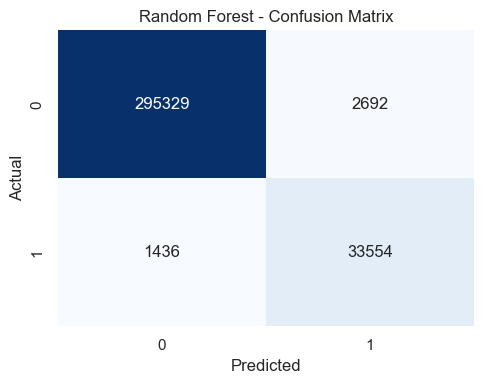


===== SGD (Linear SVM) =====
Accuracy : 0.9916
Precision: 0.9685
Recall   : 0.9511
F1-Score : 0.9597
ROC-AUC  : 0.9919
PR-AUC   : 0.9745
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    298021
           1       0.97      0.95      0.96     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.97      0.98    333011
weighted avg       0.99      0.99      0.99    333011



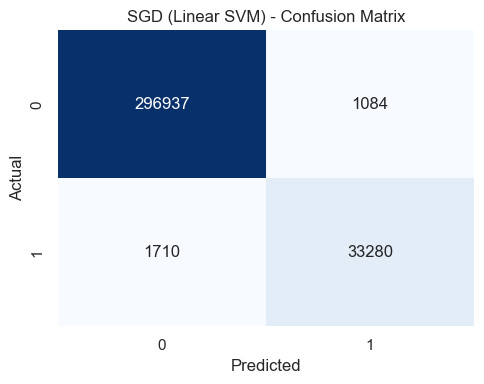


===== Logistic Regression =====
Accuracy : 0.9932
Precision: 0.9729
Recall   : 0.9619
F1-Score : 0.9674
ROC-AUC  : 0.9936
PR-AUC   : 0.9812
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    298021
           1       0.97      0.96      0.97     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.98      0.98    333011
weighted avg       0.99      0.99      0.99    333011



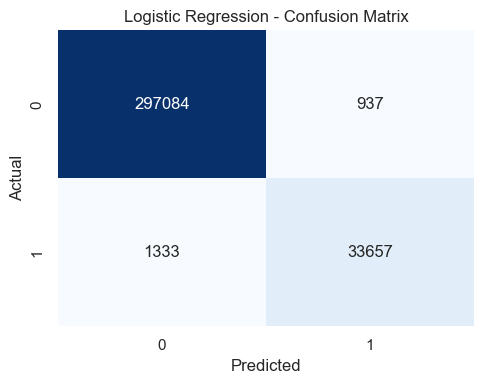


Tum modellerin karsilastirmali metrikleri:

              Model Accuracy Precision Recall F1-Score ROC-AUC PR-AUC
            XGBoost   0.9924    0.9626 0.9652   0.9639  0.9938 0.9830
      Random Forest   0.9876    0.9257 0.9590   0.9421  0.9931 0.9805
   SGD (Linear SVM)   0.9916    0.9685 0.9511   0.9597  0.9919 0.9745
Logistic Regression   0.9932    0.9729 0.9619   0.9674  0.9936 0.9812

Metrikler kaydedildi: ./plots/model_metrics.csv


In [24]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Plot dosyalari icin klasor
os.makedirs("plots", exist_ok=True)

metrics_rows = []

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")

    y_pred = model.predict(X_test)
    m = split_metrics(model, X_test, y_test)
    metrics_rows.append({"Model": model_name, **m})

    print(f"Accuracy : {m['Accuracy']:.4f}")
    print(f"Precision: {m['Precision']:.4f}")
    print(f"Recall   : {m['Recall']:.4f}")
    print(f"F1-Score : {m['F1-Score']:.4f}")
    print(f"ROC-AUC  : {m['ROC-AUC']:.4f}")
    print(f"PR-AUC   : {m['PR-AUC']:.4f}")

    # Classification Report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    # Dosyaya kaydet (or: xgboost_confusion_matrix.png)
    file_key = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"./plots/{file_key}_confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

# Tum modellerin ozet metrik tablosu
import pandas as pd

metrics_df = pd.DataFrame(metrics_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]
print("\nTum modellerin karsilastirmali metrikleri:\n")
print(metrics_df.to_string(index=False, formatters={c: "{:.4f}".format for c in metric_cols}))
metrics_df.to_csv("./plots/model_metrics.csv", index=False, float_format="%.6f")
print("\nMetrikler kaydedildi: ./plots/model_metrics.csv")

### 4.1) Imbalance-aware metrikler ve baseline

Sinif dagilimi ~%89 benign / %10 SQLi oldugu icin **accuracy tek basina yeterli degil**.
Bu hucrede:
- Majority-class baseline (hep 0 tahmin)
- Balanced accuracy, MCC, ROC-AUC, PR-AUC
- False negative / false positive ornekleri (en iyi tek model: Logistic Regression)

Ciktilar: `plots/extended_test_metrics.csv`, `plots/error_analysis_false_negatives.csv`, `plots/error_analysis_false_positives.csv`, `plots/lr_test_pr_curve.png`

=== Test set sinif dagilimi ===
  Toplam      : 333,011
  Label 0     : 298,021 (89.49%)
  Label 1     : 34,990 (10.51%)
  Majority baseline accuracy (hep 0): 0.8949

=== Genisletilmis test metrikleri ===
              Model  Accuracy  Balanced_Accuracy  Precision  Recall  F1-Score    MCC  ROC-AUC  PR-AUC
Majority (always 0)    0.8949             0.5000     0.0000  0.0000    0.0000 0.0000      NaN     NaN
            XGBoost    0.9924             0.9804     0.9626  0.9652    0.9639 0.9596   0.9938  0.9830
      Random Forest    0.9876             0.9750     0.9257  0.9590    0.9421 0.9353   0.9931  0.9805
   SGD (Linear SVM)    0.9916             0.9737     0.9685  0.9511    0.9597 0.9551   0.9919  0.9745
Logistic Regression    0.9932             0.9794     0.9729  0.9619    0.9674 0.9636   0.9936  0.9812
  XGBoost: accuracy lift vs majority = +0.0975
  Random Forest: accuracy lift vs majority = +0.0927
  SGD (Linear SVM): accuracy lift vs majority = +0.0967
  Logistic Regression: accu

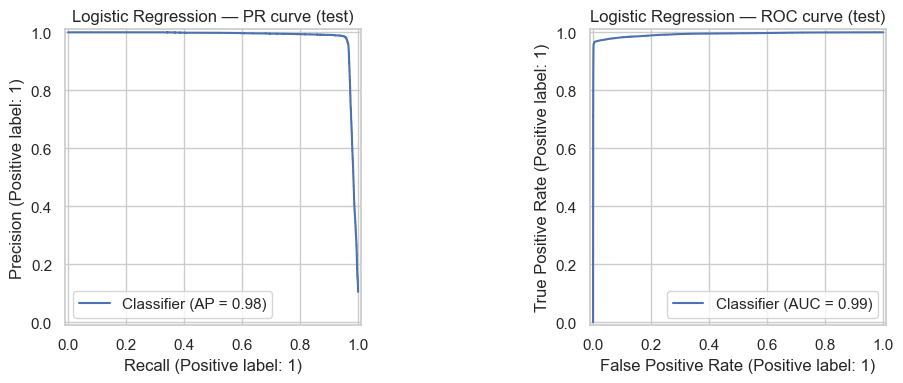


Kaydedildi: plots/extended_test_metrics.csv, plots/error_analysis_*.csv, plots/lr_test_pr_roc_curves.png


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

os.makedirs("plots", exist_ok=True)

POS_LABEL = 1
y_test_arr = np.asarray(y_test)


_positive_scores = positive_scores


def evaluate_binary(y_true, y_pred, y_score=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        out["ROC-AUC"] = roc_auc_score(y_true, y_score)
        out["PR-AUC"] = average_precision_score(y_true, y_score)
    else:
        out["ROC-AUC"] = np.nan
        out["PR-AUC"] = np.nan
    return out


# --- Dataset ve baseline ---
n_test = len(y_test_arr)
maj_ratio = (y_test_arr == 0).mean()
y_pred_majority = np.zeros_like(y_test_arr)

print("=== Test set sinif dagilimi ===")
print(f"  Toplam      : {n_test:,}")
print(f"  Label 0     : {(y_test_arr == 0).sum():,} ({100 * maj_ratio:.2f}%)")
print(f"  Label 1     : {(y_test_arr == 1).sum():,} ({100 * (1 - maj_ratio):.2f}%)")
print(f"  Majority baseline accuracy (hep 0): {maj_ratio:.4f}")

baseline_row = {"Model": "Majority (always 0)"}
baseline_row.update(evaluate_binary(y_test_arr, y_pred_majority))
extended_rows = [baseline_row]

# --- Tum modeller + genisletilmis metrikler ---
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_score = _positive_scores(model, X_test)
    row = {"Model": model_name}
    row.update(evaluate_binary(y_test_arr, y_pred, y_score))
    extended_rows.append(row)

extended_df = pd.DataFrame(extended_rows)
extended_df.to_csv("./plots/extended_test_metrics.csv", index=False, float_format="%.6f")

print("\n=== Genisletilmis test metrikleri ===")
display_cols = [
    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "MCC",
    "ROC-AUC",
    "PR-AUC",
]
print(extended_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Accuracy lift vs majority
for _, r in extended_df.iterrows():
    if r["Model"] == "Majority (always 0)":
        continue
    lift = r["Accuracy"] - maj_ratio
    print(f"  {r['Model']}: accuracy lift vs majority = +{lift:.4f}")

# --- En iyi tek model: hata analizi + PR/ROC ---
BEST_MODEL_NAME = "Logistic Regression"
best_model = models[BEST_MODEL_NAME]
y_pred_best = best_model.predict(X_test)
y_score_best = _positive_scores(best_model, X_test)

test_index = idx_test
fn_mask = (y_test_arr == 1) & (y_pred_best == 0)
fp_mask = (y_test_arr == 0) & (y_pred_best == 1)

fn_df = pd.DataFrame(
    {
        "Sentence": df.loc[test_index[fn_mask], "Sentence"].values,
        "Label": y_test_arr[fn_mask],
        "Predicted": y_pred_best[fn_mask],
        "Score": y_score_best[fn_mask],
    }
)
fp_df = pd.DataFrame(
    {
        "Sentence": df.loc[test_index[fp_mask], "Sentence"].values,
        "Label": y_test_arr[fp_mask],
        "Predicted": y_pred_best[fp_mask],
        "Score": y_score_best[fp_mask],
    }
)

fn_df.head(50).to_csv("./plots/error_analysis_false_negatives.csv", index=False)
fp_df.head(50).to_csv("./plots/error_analysis_false_positives.csv", index=False)

print(f"\n=== {BEST_MODEL_NAME} hata ozeti (test) ===")
print(f"  False negatives (SQLi kacirildi): {fn_mask.sum():,}")
print(f"  False positives (yanlis alarm)  : {fp_mask.sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PrecisionRecallDisplay.from_predictions(y_test_arr, y_score_best, ax=axes[0])
axes[0].set_title(f"{BEST_MODEL_NAME} — PR curve (test)")
RocCurveDisplay.from_predictions(y_test_arr, y_score_best, ax=axes[1])
axes[1].set_title(f"{BEST_MODEL_NAME} — ROC curve (test)")
plt.tight_layout()
plt.savefig("./plots/lr_test_pr_roc_curves.png", dpi=150)
plt.show()
plt.close()

print("\nKaydedildi: plots/extended_test_metrics.csv, plots/error_analysis_*.csv, plots/lr_test_pr_roc_curves.png")

### 4.2) Kaynak bazli test analizi

Mevcut holdout test seti, `dataset_source` (SQLiV3 / better) ile alt kume metriklerine ayrilir.
Bu, tek bir karisik testteki ortalamanin hangi kaynaktan geldigini gosterir.

Cikti: `plots/test_metrics_by_source.csv`

In [26]:
import numpy as np
import pandas as pd

os.makedirs("plots", exist_ok=True)

y_test_arr = np.asarray(y_test)
test_meta = pd.DataFrame(
    {
        "Label": y_test_arr,
        "dataset_source": df.loc[idx_test, "dataset_source"].values,
    },
    index=idx_test,
)

print("=== Test set: kaynak dagilimi ===")
print(test_meta["dataset_source"].value_counts())
print("\nLabel x kaynak (test):")
print(pd.crosstab(test_meta["Label"], test_meta["dataset_source"]))

source_rows = []
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_score = _positive_scores(model, X_test)
    for source in ["sqliv3", "better"]:
        mask = (test_meta["dataset_source"].values == source)
        if not mask.any():
            continue
        y_src = y_test_arr[mask]
        row = {
            "Model": model_name,
            "Source": source,
            "N": int(mask.sum()),
            "SQLi_support": int((y_src == 1).sum()),
        }
        row.update(evaluate_binary(y_src, y_pred[mask], y_score[mask]))
        source_rows.append(row)

by_source_df = pd.DataFrame(source_rows)
by_source_df.to_csv("./plots/test_metrics_by_source.csv", index=False, float_format="%.6f")
print("\n=== Logistic Regression — kaynak bazli test ===")
lr_src = by_source_df[by_source_df["Model"] == "Logistic Regression"]
print(lr_src.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print("\nKaydedildi: ./plots/test_metrics_by_source.csv")

=== Test set: kaynak dagilimi ===
dataset_source
better    327768
sqliv3      5243
Name: count, dtype: int64

Label x kaynak (test):
dataset_source  better  sqliv3
Label                         
0               294668    3353
1                33100    1890

=== Logistic Regression — kaynak bazli test ===
              Model Source      N  SQLi_support  Accuracy  Balanced_Accuracy  Precision  Recall  F1-Score    MCC  ROC-AUC  PR-AUC
Logistic Regression sqliv3   5243          1890    0.9023             0.9200     0.7947  0.9831    0.8789 0.8113   0.9749  0.9499
Logistic Regression better 327768         33100    0.9946             0.9796     0.9858  0.9607    0.9731 0.9702   0.9937  0.9834

Kaydedildi: ./plots/test_metrics_by_source.csv


### 4.3) Validation esik optimizasyonu

Varsayilan 0.5 esigi IDS icin her zaman uygun degildir. Logistic Regression skorlari uzerinde
validation setinde esik taranir; hedef **SQLi recall >= 0.99** iken en dusuk false positive orani secilir.

Ciktilar: `plots/threshold_sweep_validation.csv`, `plots/lr_threshold_pr_validation.png`, `plots/lr_optimal_threshold.json`

=== Optimal esik (validation, recall>=0.99) ===
  Threshold : 0.0700
  Recall    : 0.9906
  Precision : 0.3391
  FPR       : 0.2267

=== Logistic Regression @ test (esik karsilastirmasi) ===
          Rule  Accuracy  Balanced_Accuracy  Precision  Recall  F1-Score    MCC  ROC-AUC  PR-AUC
   default 0.5    0.9932             0.9794     0.9729  0.9619    0.9674 0.9636   0.9936  0.9812
optimal 0.0700    0.7956             0.8818     0.3386  0.9910    0.5047 0.5074   0.9936  0.9812


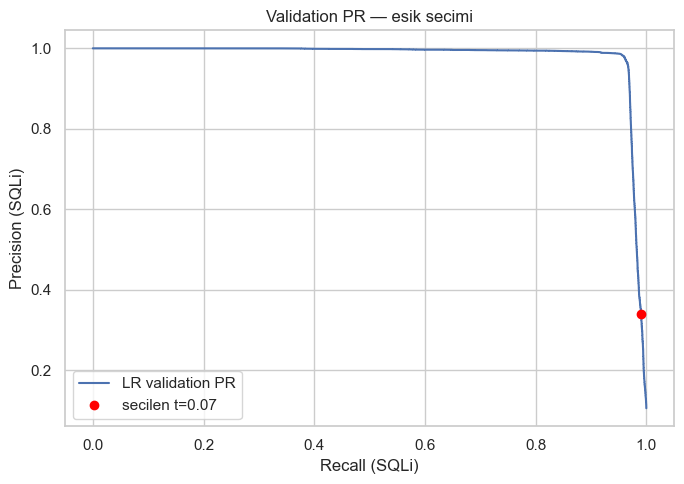


Kaydedildi: plots/threshold_sweep_validation.csv, plots/lr_optimal_threshold.json


In [27]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

TARGET_RECALL = 0.99
THRESHOLDS = np.linspace(0.01, 0.99, 99)

y_val_arr = np.asarray(y_val)
val_scores = _positive_scores(lr_model, X_val)

sweep_rows = []
for t in THRESHOLDS:
    y_pred_t = (val_scores >= t).astype(int)
    m = evaluate_binary(y_val_arr, y_pred_t)
    tn = ((y_val_arr == 0) & (y_pred_t == 0)).sum()
    fp = ((y_val_arr == 0) & (y_pred_t == 1)).sum()
    m["Threshold"] = float(t)
    m["FPR"] = fp / max((y_val_arr == 0).sum(), 1)
    sweep_rows.append(m)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv("./plots/threshold_sweep_validation.csv", index=False, float_format="%.6f")

feasible = sweep_df[sweep_df["Recall"] >= TARGET_RECALL]
if feasible.empty:
    best_row = sweep_df.loc[sweep_df["Recall"].idxmax()]
    print(f"UYARI: Validation'da recall >= {TARGET_RECALL} saglanamadi; en yuksek recall secildi.")
else:
    best_row = feasible.loc[feasible["FPR"].idxmin()]

opt_threshold = float(best_row["Threshold"])
print(f"=== Optimal esik (validation, recall>={TARGET_RECALL}) ===")
print(f"  Threshold : {opt_threshold:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  FPR       : {best_row['FPR']:.4f}")

# Test setinde ayni esik
test_scores = _positive_scores(lr_model, X_test)
y_pred_opt = (test_scores >= opt_threshold).astype(int)
test_opt = evaluate_binary(y_test_arr, y_pred_opt, test_scores)
y_pred_default = (test_scores >= 0.5).astype(int)
test_def = evaluate_binary(y_test_arr, y_pred_default, test_scores)

print("\n=== Logistic Regression @ test (esik karsilastirmasi) ===")
cmp = pd.DataFrame(
    [
        {"Rule": "default 0.5", **test_def},
        {"Rule": f"optimal {opt_threshold:.4f}", **test_opt},
    ]
)
print(cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

def _json_metrics(d):
    return {k: float(v) if isinstance(v, (int, float, np.floating)) else v for k, v in d.items()}


with open("./plots/lr_optimal_threshold.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "target_recall_validation": TARGET_RECALL,
            "optimal_threshold": opt_threshold,
            "validation_metrics": _json_metrics(best_row.to_dict()),
            "test_metrics_default_0_5": _json_metrics(test_def),
            "test_metrics_optimal": _json_metrics(test_opt),
        },
        f,
        indent=2,
    )

fig, ax = plt.subplots(figsize=(7, 5))
precision, recall, pr_thresholds = precision_recall_curve(y_val_arr, val_scores)
ax.plot(recall, precision, label="LR validation PR")
ax.scatter([best_row["Recall"]], [best_row["Precision"]], color="red", zorder=5, label=f"secilen t={opt_threshold:.2f}")
ax.set_xlabel("Recall (SQLi)")
ax.set_ylabel("Precision (SQLi)")
ax.set_title("Validation PR — esik secimi")
ax.legend()
plt.tight_layout()
plt.savefig("./plots/lr_threshold_pr_validation.png", dpi=150)
plt.show()
plt.close()
print("\nKaydedildi: plots/threshold_sweep_validation.csv, plots/lr_optimal_threshold.json")

### 4.4) Capraz kaynak OOD degerlendirme

**Senaryo:** Egitim yalnizca `better` kaynagindaki train ornekleri; test yalnizca `sqliv3` test ornekleri.
Bu, karisik train/test'ten daha sert bir genelleme testidir (farkli veri uretim dagilimi).

Not: TF-IDF vektorizeri tum train uzerinde fit edilmistir; asagidaki hucre yalnizca **siniflandirici**
agirliklarini better-alt-kume uzerinde yeniden ogrenir (hizli yaklasik OOD). Tam izolasyon icin
ayri bir pipeline'da vectorizer'i de yalnizca better train'de fit etmek gerekir.

In [28]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

train_source = df.loc[idx_train, "dataset_source"]
test_source = df.loc[idx_test, "dataset_source"]

mask_train_better = (train_source == "better").values
mask_test_sqliv3 = (test_source == "sqliv3").values

print("OOD better-train / sqliv3-test ornek sayilari:")
print(f"  Train (better) : {mask_train_better.sum():,} / {len(idx_train):,}")
print(f"  Test (sqliv3)  : {mask_test_sqliv3.sum():,} / {len(idx_test):,}")

lr_ood = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42,
)
lr_ood.fit(X_train[mask_train_better], y_train[mask_train_better])

# Tam model (tum train) — ayni sqliv3 test alt kumesi
y_pred_full = lr_model.predict(X_test[mask_test_sqliv3])
y_score_full = _positive_scores(lr_model, X_test[mask_test_sqliv3])
y_true_ood = y_test_arr[mask_test_sqliv3]

y_pred_ood = lr_ood.predict(X_test[mask_test_sqliv3])
y_score_ood = _positive_scores(lr_ood, X_test[mask_test_sqliv3])

ood_rows = [
    {"Model": "LR full train", **evaluate_binary(y_true_ood, y_pred_full, y_score_full)},
    {"Model": "LR OOD (better train)", **evaluate_binary(y_true_ood, y_pred_ood, y_score_ood)},
]
ood_df = pd.DataFrame(ood_rows)
ood_df.to_csv("./plots/cross_source_ood_sqliv3_test.csv", index=False, float_format="%.6f")

print("\n=== SQLiV3 test alt kumesi — tam train vs OOD (better-only train) ===")
print(ood_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nKaydedildi: ./plots/cross_source_ood_sqliv3_test.csv")

OOD better-train / sqliv3-test ornek sayilari:
  Train (better) : 1,114,474 / 1,132,235
  Test (sqliv3)  : 5,243 / 333,011

=== SQLiV3 test alt kumesi — tam train vs OOD (better-only train) ===
                Model  Accuracy  Balanced_Accuracy  Precision  Recall  F1-Score    MCC  ROC-AUC  PR-AUC
        LR full train    0.9023             0.9200     0.7947  0.9831    0.8789 0.8113   0.9749  0.9499
LR OOD (better train)    0.7345             0.7852     0.5789  0.9667    0.7241 0.5594   0.8839  0.7124

Kaydedildi: ./plots/cross_source_ood_sqliv3_test.csv


## 5) Ensemble (Topluluk) Mimarisi

Bu bolumde temel modeller tek bir topluluk modelinde birlestirilir.
`VotingClassifier` (soft voting) ile model olasiliklari bir araya getirilir.
Ensemble sonucu da confusion matrix olarak kaydedilir ve model `.pkl` olarak disariya yazilir.


===== Ensemble =====
Accuracy : 0.9932
Precision: 0.9707
Recall   : 0.9641
F1-Score : 0.9674
ROC-AUC  : 0.9938
PR-AUC   : 0.9837
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    298021
           1       0.97      0.96      0.97     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.98      0.98    333011
weighted avg       0.99      0.99      0.99    333011



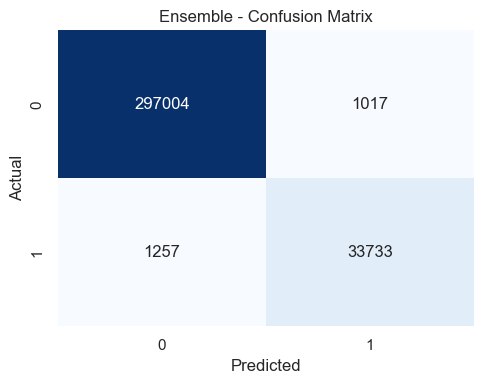

ensemble_model.pkl basariyla kaydedildi.
./plots/ensemble_confusion_matrix.png basariyla kaydedildi.


In [29]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Klasorleri garanti et
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Ensemble modeli (mevcut modellerle)
ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model),
        ("sgd", sgd_model),
        ("lr", lr_model),
    ],
    voting="soft",
    n_jobs=-1,
)

# Fit
ensemble_model.fit(X_train, y_train)

# Tahmin
y_pred_ensemble = ensemble_model.predict(X_test)

# Metrikler
ensemble_m = split_metrics(ensemble_model, X_test, y_test)
metrics_rows.append({"Model": "Ensemble", **ensemble_m})

print("\n===== Ensemble =====")
print(f"Accuracy : {ensemble_m['Accuracy']:.4f}")
print(f"Precision: {ensemble_m['Precision']:.4f}")
print(f"Recall   : {ensemble_m['Recall']:.4f}")
print(f"F1-Score : {ensemble_m['F1-Score']:.4f}")
print(f"ROC-AUC  : {ensemble_m['ROC-AUC']:.4f}")
print(f"PR-AUC   : {ensemble_m['PR-AUC']:.4f}")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))

# Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("./plots/ensemble_confusion_matrix.png", dpi=150)
plt.show()
plt.close()

# Modeli kaydet
with open("models/ensemble_model.pkl", "wb") as file:
    pickle.dump(ensemble_model, file)

print("ensemble_model.pkl basariyla kaydedildi.")
print("./plots/ensemble_confusion_matrix.png basariyla kaydedildi.")

## 6) Gorsellestirme

Tum modellerin **test** performansi karsilastirilir.
- Metrikler: Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC
- Cikti: `plots/model_performance_comparison.png`, `plots/model_metrics.csv`
- Overfitting analizi: `plots/train_val_gap.png`

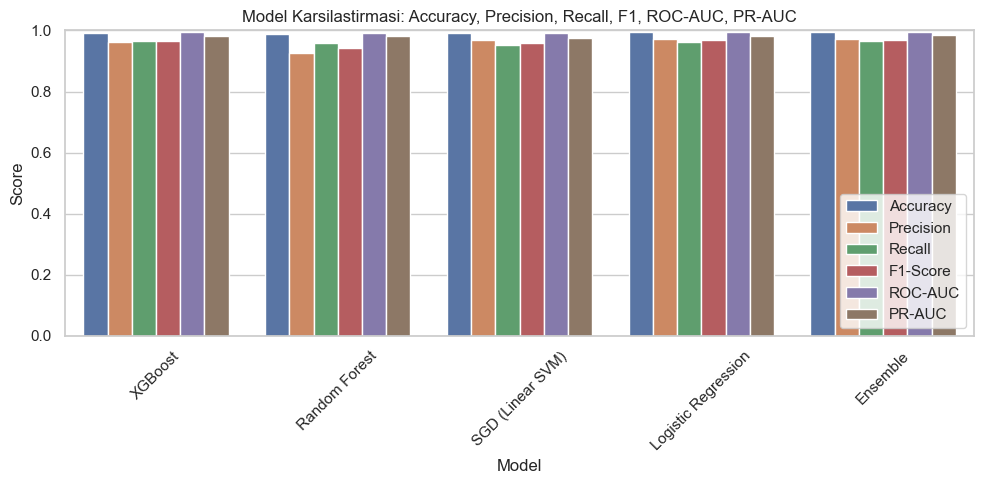

./plots/model_performance_comparison.png basariyla kaydedildi.

Tum modeller (Ensemble dahil):

              Model Accuracy Precision Recall F1-Score ROC-AUC PR-AUC
            XGBoost   0.9924    0.9626 0.9652   0.9639  0.9938 0.9830
      Random Forest   0.9876    0.9257 0.9590   0.9421  0.9931 0.9805
   SGD (Linear SVM)   0.9916    0.9685 0.9511   0.9597  0.9919 0.9745
Logistic Regression   0.9932    0.9729 0.9619   0.9674  0.9936 0.9812
           Ensemble   0.9932    0.9707 0.9641   0.9674  0.9938 0.9837


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost,0.992397,0.962576,0.965161,0.963867,0.993804,0.983018
1,Random Forest,0.987604,0.925730,0.958960,0.942052,0.993057,0.980486
2,SGD (Linear SVM),0.991610,0.968455,0.951129,0.959714,0.991892,0.974540
3,Logistic Regression,0.993183,0.972914,0.961903,0.967378,0.993616,0.981238
4,Ensemble,0.993171,0.970734,0.964075,0.967393,0.993840,0.983698


In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot klasoru garanti
os.makedirs("plots", exist_ok=True)

# metrics_rows onceki adimlardan geliyor
metrics_df = pd.DataFrame(metrics_rows)

# Dataframe'i uzun formata cevir
metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

# Barplot
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Karsilastirmasi: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./plots/model_performance_comparison.png", dpi=150)
plt.show()
plt.close()

print("./plots/model_performance_comparison.png basariyla kaydedildi.")

# Guncel metrik tablosu (Ensemble dahil)
metrics_df = pd.DataFrame(metrics_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]
print("\nTum modeller (Ensemble dahil):\n")
print(metrics_df.to_string(index=False, formatters={c: "{:.4f}".format for c in metric_cols}))
metrics_df.to_csv("./plots/model_metrics.csv", index=False, float_format="%.6f")
metrics_df